# Visium_brain01

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import time
import scanpy.external as sce

In [2]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]
import pysodb
sodb = pysodb.SODB()
adata_raw0 = sodb.load_experiment('10x','V1_Human_Brain_Section_1_filtered_feature_bc_matrix')
adata_raw1 = sodb.load_experiment('10x','V1_Human_Brain_Section_2_filtered_feature_bc_matrix')


load experiment[V1_Human_Brain_Section_1_filtered_feature_bc_matrix] in dataset[10x]
load experiment[V1_Human_Brain_Section_2_filtered_feature_bc_matrix] in dataset[10x]


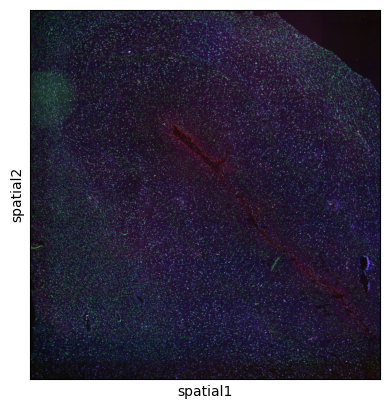

In [3]:
ax = sc.pl.spatial(adata_raw0,color=None,show=False)


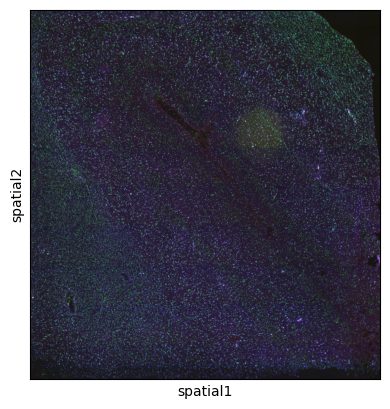

In [4]:
ax = sc.pl.spatial(adata_raw1,color=None,show=False)


In [5]:
adata_raw = adata_raw0.concatenate(adata_raw1)

In [6]:






adata = adata_raw.copy()



######### determine cell state using standard Leiden [start]  #########
# this step can be optionally skipped if reliable cell type annotation is available
# for this data, to obtain aligned "cell type" between two slices, we used harmony for integration
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=4000)
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

sc.pp.pca(adata)
sce.pp.harmony_integrate(adata, 'batch')
sc.pp.neighbors(adata,use_rep='X_pca_harmony')
sc.tl.umap(adata)

sc.tl.leiden(adata,resolution=2,key_added='ct')
adata.obs['ct'] = adata.obs['ct'].astype('category')
######### determine cell state using standard Leiden [end]  #########







2023-05-08 09:17:39,587 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2023-05-08 09:17:46,760 - harmonypy - INFO - sklearn.KMeans initialization complete.
2023-05-08 09:17:46,819 - harmonypy - INFO - Iteration 1 of 10
2023-05-08 09:17:49,947 - harmonypy - INFO - Iteration 2 of 10
2023-05-08 09:17:52,815 - harmonypy - INFO - Iteration 3 of 10
2023-05-08 09:17:56,325 - harmonypy - INFO - Iteration 4 of 10
2023-05-08 09:17:59,916 - harmonypy - INFO - Iteration 5 of 10
2023-05-08 09:18:02,952 - harmonypy - INFO - Iteration 6 of 10
2023-05-08 09:18:04,950 - harmonypy - INFO - Converged after 6 iterations


In [7]:
# input parameters of MENDER
scale = 3

msm = MENDER.MENDER(
    adata,
    batch_obs = 'batch', 
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='ct'
)


# set the MENDER parameters


msm.prepare()
msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    # for spot data, nn_mode is set to 'ring', since each spot is surrounded by certain number of spots (6 for visium and 4 for ST)
    
    nn_mode='ring',
    
    # default of n_scales is 15 um (see the manuscript for the analysis).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=6, 

)
# construct the context representation
msm.run_representation_mp(
    200
    # the number of processings
)
# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(-0.2)



default number of process is 200
total batch: 2, running batch 0
total batch: 2, running batch 1
scale 0, median #cells per ring (r=6): 7.0
scale 0, median #cells per ring (r=6): 7.0
scale 1, median #cells per ring (r=6): 12.0
scale 1, median #cells per ring (r=6): 12.0
scale 2, median #cells per ring (r=6): 18.0
scale 2, median #cells per ring (r=6): 18.0


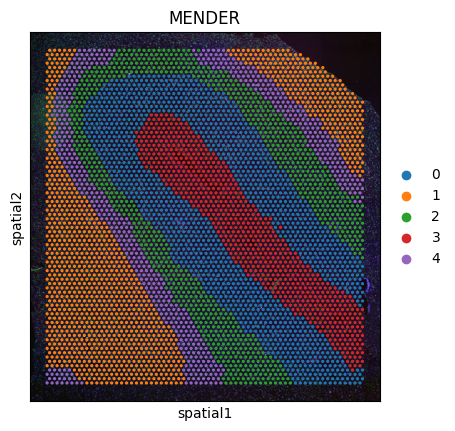

In [8]:
# output MENDER result of slice 0
adata_raw0.obs['MENDER'] = np.array(msm.adata_MENDER[msm.adata_MENDER.obs['batch']=='0'].obs['MENDER'])
ax = sc.pl.spatial(adata_raw0,color=['MENDER'])




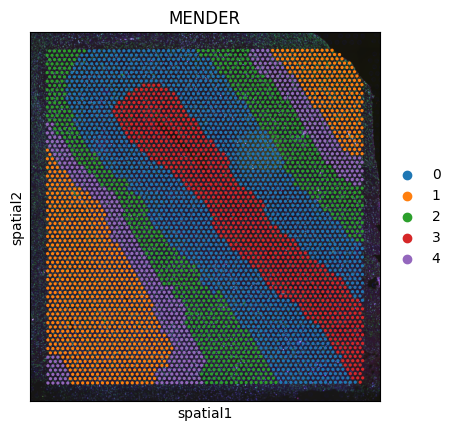

In [9]:
# output MENDER result of slice 1
adata_raw1.obs['MENDER'] = np.array(msm.adata_MENDER[msm.adata_MENDER.obs['batch']=='1'].obs['MENDER'])
ax = sc.pl.spatial(adata_raw1,color=['MENDER'])




In [10]:
msm.adata_MENDER.write_h5ad('dump/Visium_brain.h5ad')

